# Data Exploration

What the raw data looks like, why rent is modelled on a log scale, how rent differs by city, and what the cleaning
rules remove. Every number here is computed live from `data/raw/House_Rent_Dataset.csv`.
Figures are saved to `visualizations/`.

## 1. Setup

In [1]:
import sys, pathlib, warnings
ROOT = next((p for p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents) if (p / 'src' / 'config.py').exists()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the project folder (the one that contains src/).')
sys.path.insert(0, str(ROOT))   # project root -> `import src`, whatever the working folder
warnings.filterwarnings('ignore')
import pandas as pd
pd.set_option('display.float_format', '{:,.2f}'.format)
import numpy as np
import matplotlib.pyplot as plt
from src import config
from src.data_loading import load_raw
from src.data_cleaning import apply_stateless_rules, MAX_RENT_PER_SQFT
from src.plotting import apply_style, BLUE, INK_2, RENT

apply_style()
config.VIZ_DIR.mkdir(exist_ok=True)
raw = load_raw()

## 2. The raw dataset

In [2]:
print(f"{raw.shape[0]:,} rows × {raw.shape[1]} columns · missing values: {int(raw.isna().sum().sum())} · "
      f"exact duplicate rows: {int(raw.duplicated().sum())}")
pd.DataFrame({'type': raw.dtypes.astype(str), 'distinct values': raw.nunique()})

4,746 rows × 12 columns · missing values: 0 · exact duplicate rows: 0


,type,distinct values
Posted On,str,81
BHK,int64,6
Rent,int64,243
Size,int64,615
Floor,str,480
Area Type,str,3
Area Locality,str,2235
City,str,6
Furnishing Status,str,3
Tenant Preferred,str,3


`Rent` is the target. `Area Locality` has over two thousand distinct values, so it is target-encoded (inside
cross-validation) rather than one-hot encoded; the other text columns have three to six values each and are one-hot
encoded. `Floor` is text such as "3 out of 5"; it is parsed to check the listing is valid but is not used as a
feature (floor and building height changed the error by only about Rs 600). `Posted On` is the listing date (not
the build date) and is not used as a feature either.

## 3. Rent is heavily right-skewed

median Rs 16,000 · mean Rs 34,993 · max Rs 3,500,000 · skewness 21.4 → 0.91 after log(1 + rent)


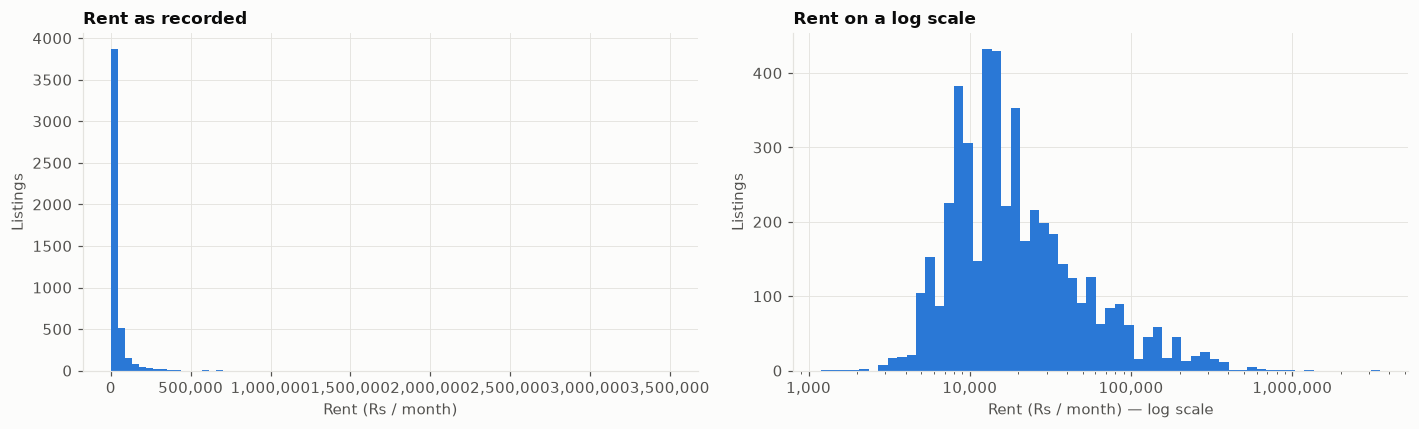

In [3]:
rent = raw['Rent']
print(f"median Rs {rent.median():,.0f} · mean Rs {rent.mean():,.0f} · max Rs {rent.max():,.0f} · "
      f"skewness {rent.skew():.1f} → {np.log1p(rent).skew():.2f} after log(1 + rent)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(rent, bins=80, color=BLUE)
ax[0].set(title='Rent as recorded', xlabel=RENT, ylabel='Listings')
ax[1].hist(rent, bins=np.logspace(np.log10(rent.min()), np.log10(rent.max()), 60), color=BLUE)
ax[1].set(xscale='log', title='Rent on a log scale', xlabel=RENT + ' — log scale', ylabel='Listings')
for a in ax:
    a.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
fig.tight_layout(); fig.savefig(config.VIZ_DIR / 'rent_distribution.png')

A few very expensive listings stretch the scale. On a log scale the distribution is close to symmetric, which is
why every model learns log(1 + rent) and converts its predictions back to rupees.

## 4. Rent by city

,listings,median,mean
City,,,
Mumbai,972,"52,000.00","85,321.20"
Delhi,605,"17,000.00","29,461.98"
Bangalore,886,"14,000.00","24,966.37"
Chennai,891,"14,000.00","21,614.09"
Hyderabad,868,"14,000.00","20,555.05"
Kolkata,524,"8,500.00","11,645.17"


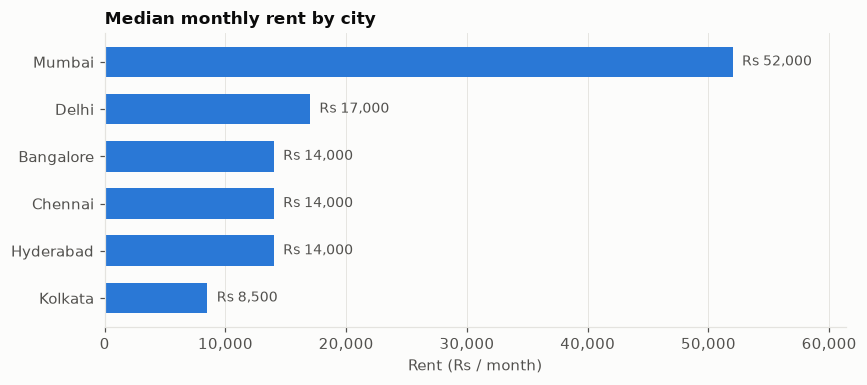

In [4]:
by_city = (raw.groupby('City')['Rent'].agg(listings='size', median='median', mean='mean')
              .sort_values('median', ascending=False))
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(by_city.index, by_city['median'], color=BLUE, height=0.65)
for y, v in enumerate(by_city['median']):
    ax.text(v + by_city['median'].max() * 0.015, y, f'Rs {v:,.0f}', va='center', color=INK_2, fontsize=9)
ax.invert_yaxis(); ax.grid(axis='y', visible=False)
ax.set(title='Median monthly rent by city', xlabel=RENT, xlim=(0, by_city['median'].max() * 1.18))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
fig.tight_layout(); fig.savefig(config.VIZ_DIR / 'rent_by_city.png')
by_city

Mumbai's median rent is several times that of any other city, so city enters the models both on its own (one-hot)
and multiplied with log(size) — a square foot costs a different amount in each city.

## 5. What drives rent (linear correlation with log rent)

In [5]:
num = raw[['BHK', 'Size', 'Bathroom']].assign(log_rent=np.log1p(raw['Rent']))
num.corr()['log_rent'].drop('log_rent').sort_values(ascending=False).to_frame('correlation with log rent')

,correlation with log rent
Bathroom,0.69
BHK,0.60
Size,0.57


## 6. What the cleaning rules remove

In [6]:
clean, log = apply_stateless_rules(raw)
print(f"{len(raw):,} → {len(clean):,} rows")
log.set_index('rule')

4,746 → 4,731 rows


,rows_before,rows_after,rows_removed
rule,,,
rule_strip_text,4746,4746,0
rule_validity,4746,4746,0
rule_rent_per_sqft,4746,4740,6
rule_dedup_relisted,4740,4731,9
rule_parse_floor,4731,4731,0


In [7]:
rps = raw['Rent'] / raw['Size']
removed = raw.loc[rps > MAX_RENT_PER_SQFT, ['City', 'BHK', 'Size', 'Bathroom', 'Rent']].assign(
    rent_per_sqft=rps[rps > MAX_RENT_PER_SQFT]).sort_values('rent_per_sqft', ascending=False)
print(f"Listings above Rs {MAX_RENT_PER_SQFT} per sq ft per month (city medians: "
      + ", ".join(f"{c} {v:.0f}" for c, v in rps.groupby(raw['City']).median().sort_values().items()) + ")")
removed

Listings above Rs 500 per sq ft per month (city medians: Kolkata 13, Hyderabad 15, Chennai 16, Bangalore 18, Delhi 29, Mumbai 71)


,City,BHK,Size,Bathroom,Rent,rent_per_sqft
4653,Hyderabad,3,10,3,15000,"1,500.00"
1837,Bangalore,3,2500,3,3500000,"1,400.00"
4004,Hyderabad,2,130,2,130000,"1,000.00"
2656,Delhi,5,200,5,190000,950.00
3922,Hyderabad,3,25,3,23000,920.00
3656,Chennai,2,950,2,600000,631.58


These six are entry errors — flats of 10–200 sq ft with three to five bedrooms, or Rs 35 lakh a month for a
2,500 sq ft flat. Left in, the Rs 35 lakh listing alone dominated test RMSE whenever it fell in a test split. The
nine re-listings are exact duplicates apart from the posting date. Expensive but plausible listings are kept; only an
extra far-out rent-per-sq-ft filter is applied, to the **training** rows of each split (never validation or test).